In [70]:
import os
import re
import torch 
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch.optim as optim
from scipy.signal import welch
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pickle

In [71]:
# Analyzing dataset
dataset = "./combined/"
dataset_actions = {}

for root, dirs, files in os.walk(dataset):
    for file in files:
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        if action not in dataset_actions:
            dataset_actions[action] = 1
        else:
            dataset_actions[action] += 1

Dataset_actions_log = "Dataset Actions Count\n"
total = 0
for key, value in dataset_actions.items():
    total += value
    Dataset_actions_log += f"{key}: {value} | "
Dataset_actions_log += f"total: {total}"
print(Dataset_actions_log)

Dataset Actions Count
BOMB: 400 | CAPT: 400 | HULK: 400 | IDLE: 208 | IRONMAN: 400 | LOGOUT: 399 | RELOAD: 400 | SHANGCHI: 403 | SHIELD: 401 | total: 3411


In [72]:
# Read in dataset into a dataframe of 7 columns, 6 measurement columns, 1 label
# each row has 6 lists, 1 label corresponding to 1 file
dataset = "./combined/"
dataset_pd = pd.DataFrame(columns=["x_acc", "y_acc", "z_acc", "x_gyro", "y_gyro", "z_gyro", "action"])

for root, dirs, files in os.walk(dataset):
    for file in files:
        file_path = os.path.join(root, file)
        file_pd = pd.read_csv(file_path)
        x_acc = file_pd.iloc[:, 0].tolist()
        y_acc = file_pd.iloc[:, 1].tolist()
        z_acc = file_pd.iloc[:, 2].tolist()
        x_gyro = file_pd.iloc[:, 3].tolist()
        y_gyro = file_pd.iloc[:, 4].tolist()
        z_gyro = file_pd.iloc[:, 5].tolist()
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        row = {"x_acc": x_acc, "y_acc": y_acc, "z_acc": z_acc, "x_gyro": x_gyro, "y_gyro": y_gyro, "z_gyro": z_gyro, "action": action}
        dataset_pd = pd.concat([dataset_pd, pd.DataFrame([row])], ignore_index=True)

In [73]:
print(dataset_pd.shape)
dataset_pd.to_csv("full.csv")

(3411, 7)


In [75]:
max_time = 0

all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_skew = skew(data)
        t_kurtosis = kurtosis(data)
        #t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        #t_75_q = np.percentile(data, 75)

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        #f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            f"t_skew_{col_name}": t_skew,
            f"t_50_q_{col_name}": t_50_q,
            f"t_kurtosis_{col_name}": t_kurtosis,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            f"f_total_power_{col_name}": f_total_power,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)

label_encoder = LabelEncoder()
all_features['label'] = label_encoder.fit_transform(all_features['label'])
for label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_label}")

print(all_features.shape)

BOMB: 0
CAPT: 1
HULK: 2
IDLE: 3
IRONMAN: 4
LOGOUT: 5
RELOAD: 6
SHANGCHI: 7
SHIELD: 8
(3411, 55)


In [76]:
all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_skew = skew(data)
        t_kurtosis = kurtosis(data)
        #t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        #t_75_q = np.percentile(data, 75)

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        #f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            f"t_skew_{col_name}": t_skew,
            f"t_50_q_{col_name}": t_50_q,
            f"t_kurtosis_{col_name}": t_kurtosis,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            f"f_total_power_{col_name}": f_total_power,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)
X = all_features.drop(columns=['label'])  # Features
y = all_features['label']  # Labels


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1244)
scaler = StandardScaler()
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_norm = min_max_scaler.fit_transform(X_train_scaled)

# Save the scaler and min-max scaler objects
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('min_max_scaler.pkl', 'wb') as min_max_scaler_file:
    pickle.dump(min_max_scaler, min_max_scaler_file)

# Apply the same scaling and normalization to the test features
X_test_scaled = scaler.transform(X_test)
X_test_scaled_norm = min_max_scaler.transform(X_test_scaled)

# Convert labels to numeric values using label encoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = torch.tensor(self.features[idx], dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return features, label

# Create dataset instances
train_dataset = CustomDataset(X_train_scaled_norm, y_train_encoded)
test_dataset = CustomDataset(X_test_scaled_norm, y_test_encoded)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [78]:
class Sample_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(54, 36)  # Input layer: 6 neurons, Hidden Layer: 4 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc2 = nn.Linear(36, 18)  # Hidden layer: 4 neurons, Output Layer: 2 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc3 = nn.Linear(18, 9)


    def forward(self, x):
        m = nn.ReLU()
        x = self.fc1(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_1 = x
        x = self.fc2(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_2 = x
        x = self.fc3(x)
        intermediate_3 = x
        output = F.softmax(x, dim=1)  # dimension 1: softmax function applied along second dimension of the tensor
        return output, intermediate_1, intermediate_2, intermediate_3

In [79]:
#train_data, test_data = train_test_split(all_features, test_size=0.25, random_state=69)  # my favorite number

#batch_size = 32
#train_dataset = Sample_NN_dataset(train_data, train=True)
#test_dataset = Sample_NN_dataset(test_data, train=False)

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
epochs = 500
model = Sample_NN()
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()  # Sets the model to training mode
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the gradients
        outputs, _ , _ , _  = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            outputs, _ , _ , _  = model(inputs)
            _, predicted = torch.max(outputs, 1)  # we dont need all the maximum of a tensor, hence _
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    print(f'Epoch [{epoch + 1}/{epochs}], Test Accuracy: {accuracy:.2%}')


Epoch [1/500], Test Accuracy: 12.66%
Epoch [2/500], Test Accuracy: 12.66%
Epoch [3/500], Test Accuracy: 12.66%
Epoch [4/500], Test Accuracy: 12.66%
Epoch [5/500], Test Accuracy: 12.66%
Epoch [6/500], Test Accuracy: 12.66%
Epoch [7/500], Test Accuracy: 12.66%
Epoch [8/500], Test Accuracy: 12.66%
Epoch [9/500], Test Accuracy: 12.66%
Epoch [10/500], Test Accuracy: 12.66%
Epoch [11/500], Test Accuracy: 16.65%
Epoch [12/500], Test Accuracy: 24.74%
Epoch [13/500], Test Accuracy: 29.31%
Epoch [14/500], Test Accuracy: 32.59%
Epoch [15/500], Test Accuracy: 34.47%
Epoch [16/500], Test Accuracy: 28.37%
Epoch [17/500], Test Accuracy: 27.78%
Epoch [18/500], Test Accuracy: 32.59%
Epoch [19/500], Test Accuracy: 41.15%
Epoch [20/500], Test Accuracy: 50.29%
Epoch [21/500], Test Accuracy: 54.98%
Epoch [22/500], Test Accuracy: 56.15%
Epoch [23/500], Test Accuracy: 60.14%
Epoch [24/500], Test Accuracy: 64.83%
Epoch [25/500], Test Accuracy: 66.82%
Epoch [26/500], Test Accuracy: 67.41%
Epoch [27/500], Test 

In [80]:
from torch.utils.data import Dataset, DataLoader, ConcatDataset
combined_loader = ConcatDataset([train_loader.dataset, test_loader.dataset])
combined_loader = DataLoader(combined_loader, batch_size=batch_size, shuffle=True)


log_file = open("evaluation_logs.txt", "w")
file_path = "evaluation_logs.csv"
import csv

# Write the list to a CSV file
with open(file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0

        for inputs, labels in combined_loader:  # Assuming you have a DataLoader for the whole dataset
            outputs, _, _, _ = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Get the predicted class indices
            total += labels.size(0)
            correct += (predicted == labels).sum().item()  # Count correct predictions

            # Write inputs, labels, and outputs to the log file only when true label is 0
            for input, label, output in zip(inputs, labels, outputs):
                if label == 0:
                    log_file.write("Inputs:\n")
                    log_file.write(str(input))
                    log_file.write("\n\n")
                    writer.writerow(input.tolist())

                    log_file.write("Labels:\n")
                    log_file.write(str(label))
                    log_file.write("\n\n")

                    log_file.write("Outputs:\n")
                    log_file.write(str(output))
                    log_file.write("\n\n")

# Close the log file
log_file.close()


# Calculate accuracy
accuracy = correct / total
print(f"Correct Predictions: {correct}")
print(f"Total Samples: {total}")
print(f"Accuracy: {accuracy:.2%}")


Correct Predictions: 3380
Total Samples: 3411
Accuracy: 99.09%


In [81]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [82]:
n_splits = 5

# Define the number of folds
n_splits = 5

# Initialize k-fold cross-validation
k_folds = KFold(n_splits=n_splits, shuffle=True, random_state=1242)

# List to store accuracies for each fold
accuracies = []

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(k_folds.split(train_dataset)):
    print(f"Fold {fold + 1}/{n_splits}")
    
    # Extract training and validation data for this fold
    train_data_fold = torch.utils.data.Subset(train_dataset, train_index)
    test_data_fold = torch.utils.data.Subset(train_dataset, test_index)
    
    # Create DataLoader instances for training and validation data
    train_loader_fold = torch.utils.data.DataLoader(train_data_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = torch.utils.data.DataLoader(test_data_fold, batch_size=batch_size, shuffle=False)
    
    # Create a new instance of your model for each fold
    model = Sample_NN()
    
    # Define optimizer and loss function
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Train the model
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader_fold:
            optimizer.zero_grad()
            outputs, _, _, _ = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # Evaluate the model on the validation data for this fold
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader_fold:
            outputs, _, _, _ = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Calculate accuracy for this fold
    fold_accuracy = correct / total
    accuracies.append(fold_accuracy)
    print(f"Validation Accuracy for Fold {fold + 1}: {fold_accuracy:.2%}")

# Calculate and print average accuracy across all folds
average_accuracy = np.mean(accuracies)
print(f"\nAverage Validation Accuracy Across {n_splits} Folds: {average_accuracy:.2%}")


Fold 1/5
Validation Accuracy for Fold 1: 98.44%
Fold 2/5
Validation Accuracy for Fold 2: 98.24%
Fold 3/5
Validation Accuracy for Fold 3: 98.05%
Fold 4/5
Validation Accuracy for Fold 4: 92.17%
Fold 5/5
Validation Accuracy for Fold 5: 97.85%

Average Validation Accuracy Across 5 Folds: 96.95%


27
Input size: torch.Size([32, 54])
tensor([0.2491, 0.4149, 0.6194, 0.3501, 0.2457, 0.0191, 0.8260, 0.2001, 0.5176,
        0.8781, 0.7605, 0.7546, 0.4883, 0.8119, 0.0899, 0.1791, 0.4239, 0.6110,
        0.8132, 0.7714, 0.6887, 0.2139, 0.9093, 0.0296, 0.6031, 0.5225, 0.3732,
        0.4113, 0.5045, 0.4947, 0.3980, 0.4169, 0.1039, 0.2030, 0.1789, 0.2558,
        0.5595, 0.6143, 0.6296, 0.3007, 0.5967, 0.0616, 0.7263, 0.2359, 0.4896,
        0.5476, 0.8000, 0.8176, 0.4311, 0.4331, 0.0545, 0.6040, 0.4770, 0.7421])
tensor([ 21.8175,  43.1022,  -9.7450, -11.5016, -20.7271,  25.8492, -31.4410,
          1.6044, -25.1032], grad_fn=<SelectBackward0>)
1
1
tensor([0.4712, 0.5712, 0.5361, 0.3672, 0.4275, 0.0238, 0.4051, 0.5058, 0.3148,
        0.6787, 0.4167, 0.4017, 0.3515, 0.7427, 0.2875, 0.0948, 0.2278, 0.1739,
        0.8731, 0.4002, 0.5101, 0.3270, 0.8499, 0.0197, 0.3668, 0.6754, 0.2775,
        0.3789, 0.4912, 0.4817, 0.4350, 0.4079, 0.0712, 0.1456, 0.1126, 0.2434,
        0.4835, 0.7918, 0

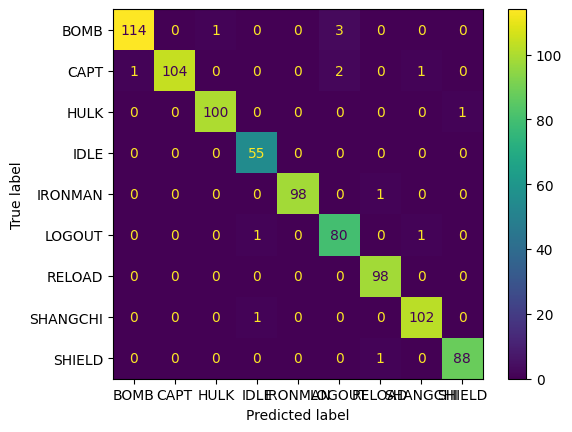

In [85]:
true_labels = []
predicted_labels = []

print(len(test_loader))
inputs, lcheck = next(iter(test_loader))

# Print the shape of the input tensor
print("Input size:", inputs.size())

for inputs, labels in test_loader:
    outputs, _, _, three = model(inputs)
    _, predicted = torch.max(outputs, 1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted.numpy())
    print(inputs[0])
    print(three[0])
    print(predicted_labels[0])
    print(true_labels[0])

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels = ["BOMB", "CAPT","HULK", "IDLE", "IRONMAN", "LOGOUT","RELOAD", "SHANGCHI", "SHIELD"])
cm_display.plot()
plt.show()

print(test_loader)

In [39]:
ll = [0.3046, 0.7193, 0.6704, 0.3721, 0.2357, 0.0187, 0.8623, 0.1067, 0.4780,
        0.4136, 0.2530, 0.3043, 0.5344, 0.4796, 0.1054, 0.4009, 0.1240, 0.1330,
        0.2945, 0.5003, 0.5310, 0.2218, 0.4113, 0.0317, 0.3493, 0.2564, 0.2690,
        0.4048, 0.6598, 0.6581, 0.3819, 0.4045, 0.0438, 0.6704, 0.6471, 0.4382,
        0.4396, 0.7876, 0.7877, 0.3589, 0.4158, 0.0275, 0.7618, 0.3729, 0.6276,
        0.2239, 0.4045, 0.4384, 0.2986, 0.2973, 0.1271, 0.6328, 0.0450, 0.2286]
tensor2 = torch.Tensor([ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll, ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll])

output, one, two, three = model(tensor2)
print(f"output: {output}")
print(f"one: {one}")
print(f"two: {two}")
print(f"three: {three}")

output: tensor([[9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1.3251e-10, 6.2507e-11],
        [9.9983e-01, 2.0471e-08, 2.3944e-05, 1.0720e-10, 4.2491e-09, 2.0215e-12,
         1.5066e-04, 1

In [40]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [41]:
model_weights_path = 'model_weights_biases.pth'
model.load_state_dict(torch.load(model_weights_path))
txt_path = 'model_parameters.txt'
all_weights_and_biases = []
with open(txt_path, 'w') as f:
    for name, param in model.named_parameters():
        # f.write(f"{name}:\n")
        print(name)
        flattened_param = param.flatten().tolist()  # Flatten the parameter tensor
        all_weights_and_biases += flattened_param
        # f.write(f"{flattened_param}\n\n")
        print(len(flattened_param))
    multiplied_list = [int(element * 10000000) for element in all_weights_and_biases]
    f.write(f"{multiplied_list}")
 

print(len(all_weights_and_biases))

print("Model parameters saved to:", txt_path)

fc1.weight
1944
fc1.bias
36
fc2.weight
648
fc2.bias
18
fc3.weight
162
fc3.bias
9
2817
Model parameters saved to: model_parameters.txt


In [42]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import os
import pickle

model_weights_path = 'model_weights_biases.pth'
model = Sample_NN()
model.load_state_dict(torch.load(model_weights_path))
model.eval()

# Load scaler and min-max scaler
with open('./scaler.pkl', 'rb') as scaler_file:
    scaler = pickle.load(scaler_file)

with open('./min_max_scaler.pkl', 'rb') as min_max_scaler_file:
    min_max_scaler = pickle.load(min_max_scaler_file)


# Function to process a CSV file
def process_csv(file_path):
    df = pd.read_csv(file_path)
    processed_features = []
    for i in range(6):
        column_list = df.iloc[:, i].tolist()
        t_mean = np.mean(column_list)
        t_std_deviation = np.std(column_list)
        t_rms = np.sqrt(np.mean(np.square(column_list)))
        t_skew = skew(column_list)
        t_kurtosis = kurtosis(column_list)
        t_50_q = np.percentile(column_list, 50)
        freq_domain = np.fft.rfft(column_list)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        processed_features +=  [t_mean, t_std_deviation, t_rms, t_skew,t_50_q,t_kurtosis, f_mean, f_max, f_total_power]

    processed_features = np.array(processed_features).reshape(1,-1)
    scaled_test_point = scaler.transform(processed_features)
    normalized_test_point = min_max_scaler.transform(scaled_test_point)
    check = normalized_test_point.tolist()[0][0]

    return normalized_test_point

encoding = {
    "BOMB": 0, "CAPT": 1, "HULK": 2, "IDLE": 3, "IRONMAN": 4, "LOGOUT": 5, "RELOAD": 6, "SHANGCHI": 7,"SHIELD": 8
}

# Run the model on all CSV files in the directory "./all"
correct = 0 
wrong = 0

for file_name in os.listdir('./combined'):
    sub = file_name
    sub = re.sub(r'\d+', '', sub)
    sub = re.sub(r'\.csv', '', sub)
    true_label = encoding[sub]
    if file_name.endswith('.csv'):
        normalized_test_point = process_csv(os.path.join('./combined/', file_name))

        with torch.no_grad():
            output, one, two, three = model(torch.Tensor(normalized_test_point))
            #if val:
                #print("output", output)
                #print("one",one)
                #print("two", two)
                #print("three", three)
            _, predicted_index = torch.max(output, 1)
            predicted_index = predicted_index.item()
            print("predicted_index: ", predicted_index, "| true_label: ", true_label, "|" ,sub)
            if predicted_index == true_label:
                correct += 1
            else:
                wrong += 1

print(correct)
print(wrong)
print(correct+ wrong)

predicted_index:  3 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  3 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label

In [43]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import os
import pickle

model_weights_path = 'model_weights_biases.pth'
model = Sample_NN()
model.load_state_dict(torch.load(model_weights_path))
model.eval()

# Load scaler and min-max scaler
with open('./scaler.pkl', 'rb') as scaler_file:
    scaler = pickle.load(scaler_file)

with open('./min_max_scaler.pkl', 'rb') as min_max_scaler_file:
    min_max_scaler = pickle.load(min_max_scaler_file)


# Function to process a CSV file
def process_csv(file_path):
    df = pd.read_csv(file_path)
    processed_features = []
    for i in range(6):
        column_list = df.iloc[:, i].tolist()
        t_mean = np.mean(column_list)
        t_std_deviation = np.std(column_list)
        t_rms = np.sqrt(np.mean(np.square(column_list)))
        t_skew = skew(column_list)
        t_kurtosis = kurtosis(column_list)
        t_50_q = np.percentile(column_list, 50)
        freq_domain = np.fft.rfft(column_list)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        processed_features +=  [t_mean, t_std_deviation, t_rms, t_skew,t_50_q,t_kurtosis, f_mean, f_max, f_total_power]

    processed_features = np.array(processed_features).reshape(1,-1)
    scaled_test_point = scaler.transform(processed_features)
    normalized_test_point = min_max_scaler.transform(scaled_test_point)
    check = normalized_test_point.tolist()[0][0]

    return normalized_test_point

encoding = {
    "BOMB": 0, "CAPT": 1, "HULK": 2, "IDLE": 3, "IRONMAN": 4, "LOGOUT": 5, "RELOAD": 6, "SHANGCHI": 7,"SHIELD": 8
}

# Run the model on all CSV files in the directory "./all"
correct = 0 
wrong = 0

log_file = open("checkpreprocess.txt", "w")
file_path = "checkpreprocess2.csv"
import csv

# Write the list to a CSV file
with open(file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    for file_name in os.listdir('./all_zip/all'):
        if file_name == "BOMB2.csv":
        #if 'BOMB' in file_name:
            normalized_test_point = process_csv(os.path.join('./all_zip/all', file_name))
            writer.writerow(normalized_test_point[0])





print(correct)
print(wrong)
print(correct+ wrong)

0
0
0
